# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')


# 1. Leitura dos dados

In [2]:
##data = pd.read_csv('RECLAMEAQUI_PAODEACUCAR.csv')
data = pd.read_csv('dataset\\RECLAMEAQUI_PAODEACUCAR.csv')

data


,ID,TEMA,LOCAL,TEMPO,CATEGORIA,STATUS,DESCRICAO,URL,ANO,MES,DIA,DIA_DO_ANO,SEMANA_DO_ANO,DIA_DA_SEMANA,TRIMETRES,CASOS
0,147765939,Preço na prateleira diferente do que está no c...,Campinas - SP,2022-01-08,Pão de Açúcar<->Supermercados<->Propaganda eng...,Resolvido,Alegando erro operacional mas que se repete se...,https://www.reclameaqui.com.br//pao-de-acucar/...,2022,1,8,8,1,5,1,24
1,147699053,UTILIZAÇÃO INDEVIDA DOS MEUS STIX,São Paulo - SP,2022-01-08,Clubes de Compras e Vantagens<->Pão de Açúcar<...,Resolvido,Estou chocada pois acabei de ver um e-mail na ...,https://www.reclameaqui.com.br//pao-de-acucar/...,2022,1,8,8,1,5,1,24
2,147700991,Não recebi meu estorno,Rio de Janeiro - RJ,2022-01-08,Supermercados<->Não encontrei meu problema<->P...,Respondida,"Fiz um reclamação semana passada, devido uma c...",https://www.reclameaqui.com.br//pao-de-acucar/...,2022,1,8,8,1,5,1,24
3,147703729,Tiraram pontos stix da conta.,São Paulo - SP,2022-01-08,Clubes de Compras e Vantagens<->Pão de Açúcar<...,Respondida,Conclui minha a meta gasto mensal no programa ...,https://www.reclameaqui.com.br//pao-de-acucar/...,2022,1,8,8,1,5,1,24
4,147705769,[Editado pelo Reclame Aqui] pontos stix,São Paulo - SP,2022-01-08,Clubes de Compras e Vantagens<->Pão de Açúcar<...,Respondida,Pela segunda vez no mesmo mês tive meus pontos...,https://www.reclameaqui.com.br//pao-de-acucar/...,2022,1,8,8,1,5,1,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,150028525,Não entregam nunca no horário limite,São Paulo - SP,2022-12-09,Atraso na entrega<->Supermercados<->Pão de Açúcar,Respondida,"Sempre que peço no site do pão de açúcar, agen...",https://www.reclameaqui.com.br//pao-de-acucar/...,2022,12,9,343,49,4,4,18
996,150029021,Pão de Açúcar e a dívida que desconheço.,São Paulo - SP,2022-12-09,Pão de Açúcar<->Não encontrei meu problema<->C...,Não respondida,"A empresa ITAPEVA, tem negativado meu nome com...",https://www.reclameaqui.com.br//pao-de-acucar/...,2022,12,9,343,49,4,4,18
997,150029875,Desconto 20% em Vinhos não concedido,Rio Negrinho - SC,2022-12-09,Pão de Açúcar<->Divergência de valores<->Bebidas,Não respondida,No dia 22/08/2022 realizei uma compra de vinho...,https://www.reclameaqui.com.br//pao-de-acucar/...,2022,12,9,343,49,4,4,18
998,149991011,itens faltantes,São Paulo - SP,2022-12-09,Pão de Açúcar<->Hipermercados<->Entrega faltan...,Não respondida,Fiz uma compra no site do pão de açucar e veio...,https://www.reclameaqui.com.br//pao-de-acucar/...,2022,12,9,343,49,4,4,18


# 2. Análise estrutural do dataset

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             1000 non-null   int64 
 1   TEMA           1000 non-null   object
 2   LOCAL          1000 non-null   object
 3   TEMPO          1000 non-null   object
 4   CATEGORIA      1000 non-null   object
 5   STATUS         1000 non-null   object
 6   DESCRICAO      1000 non-null   object
 7   URL            1000 non-null   object
 8   ANO            1000 non-null   int64 
 9   MES            1000 non-null   int64 
 10  DIA            1000 non-null   int64 
 11  DIA_DO_ANO     1000 non-null   int64 
 12  SEMANA_DO_ANO  1000 non-null   int64 
 13  DIA_DA_SEMANA  1000 non-null   int64 
 14  TRIMETRES      1000 non-null   int64 
 15  CASOS          1000 non-null   int64 
dtypes: int64(9), object(7)
memory usage: 125.1+ KB


In [4]:
# Transformar todos os nomes das colunas em letras minúsculas
data.columns = data.columns.str.lower()

data.columns.tolist()

['id',
 'tema',
 'local',
 'tempo',
 'categoria',
 'status',
 'descricao',
 'url',
 'ano',
 'mes',
 'dia',
 'dia_do_ano',
 'semana_do_ano',
 'dia_da_semana',
 'trimetres',
 'casos']

In [5]:
# Primeira visão de variáveis categóricas chave. Contagem de valores únicos
print(f"~> Número de temas únicos: {data['tema'].nunique()}")
print(f"~> Número de locais únicos: {data['local'].nunique()}")
print(f"~> Número de datas únicas: {data['tempo'].nunique()}")
print(f"~> Número de categorias únicas: {data['categoria'].nunique()}")
print(f"~> Número de descrições únicas: {data['descricao'].nunique()}")
print(f"~> Padrões de status únicos: {data['status'].unique().tolist()}")

~> Número de temas únicos: 944
~> Número de locais únicos: 135
~> Número de datas únicas: 71
~> Número de categorias únicas: 210
~> Número de descrições únicas: 989
~> Padrões de status únicos: ['Resolvido', 'Respondida', 'Em réplica', 'Não respondida', 'Não resolvido']


# 3. Análise Exploratória de Dados

In [6]:
# Realizar a verificação se há alguma coluna com pelo menos um valor nulo.
print('_' * 42)
print(f'|{'Valores nulos por coluna': ^40}|')
print('-' * 42)

for i in data.columns:
    print(f'|{i: <20}',end='')
    print(f'{data[i].isna().sum(): >20}|')
    
print('-' * 42)

__________________________________________
|        Valores nulos por coluna        |
------------------------------------------
|id                                     0|
|tema                                   0|
|local                                  0|
|tempo                                  0|
|categoria                              0|
|status                                 0|
|descricao                              0|
|url                                    0|
|ano                                    0|
|mes                                    0|
|dia                                    0|
|dia_do_ano                             0|
|semana_do_ano                          0|
|dia_da_semana                          0|
|trimetres                              0|
|casos                                  0|
------------------------------------------


In [7]:
print('_' * 110)
print(f'|{'Valores nulos por coluna': ^78}|')
print('-' * 110)
data.describe().T

______________________________________________________________________________________________________________
|                           Valores nulos por coluna                           |
--------------------------------------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
id,1000.0,1.485025e+08,1.139302e+06,146345143.0,147598303.5,148473420.0,149516314.5,150438193.0
ano,1000.0,2.022000e+03,0.000000e+00,2022.0,2022.0,2022.0,2022.0,2022.0
mes,1000.0,7.272000e+00,2.506052e+00,1.0,7.0,8.0,8.0,12.0
dia,1000.0,1.551700e+01,7.397461e+00,7.0,9.0,14.0,21.0,31.0
dia_do_ano,1000.0,2.053620e+02,7.769883e+01,8.0,194.0,221.0,243.0,343.0
semana_do_ano,1000.0,2.950700e+01,1.113759e+01,1.0,28.0,32.0,35.0,49.0
dia_da_semana,1000.0,2.813000e+00,1.864808e+00,0.0,1.0,3.0,4.0,6.0
trimetres,1000.0,2.786000e+00,7.891938e-01,1.0,3.0,3.0,3.0,4.0
casos,1000.0,1.663000e+01,5.821597e+00,2.0,14.0,17.0,21.0,33.0


In [8]:
# Contagem de valores únicos por coluna
data.nunique()


id                996
tema              944
local             135
tempo              71
categoria         210
status              5
descricao         989
url              1000
ano                 1
mes                12
dia                22
dia_do_ano         71
semana_do_ano      21
dia_da_semana       7
trimetres           4
casos              25
dtype: int64

# 4. Tratamento de Dados

In [9]:
# Remoção de linhas duplicadas (exceto coluna URL)
data = data.drop_duplicates(subset=data.columns.drop('url')).copy()

print(f'Shape após remoção de duplicatas: {data.shape}')


Shape após remoção de duplicatas: (996, 16)


## 4.1 Limpeza de espaços extras (strip)

In [10]:
# Remover espaços extras no início e fim das colunas de texto
#data.columns = data.columns.str.lower()
str_cols = ['tema', 'local', 'tempo', 'categoria', 'status', 'descricao']
for col in str_cols:
    data[col] = data[col].str.strip()

print('Strip aplicado nas colunas:', str_cols)

Strip aplicado nas colunas: ['tema', 'local', 'tempo', 'categoria', 'status', 'descricao']


## 4.2 Padronização de capitalização da coluna CATEGORIA

In [11]:
# Antes da padronização: checar variações de capitalização
print('Antes:')
cats_antes = data['categoria'].str.split('<->').explode().str.strip()
print(cats_antes[cats_antes.str.lower().str.contains('propaganda')].unique())

# Padronizar para title case (primeira letra maiúscula em cada palavra)
data['categoria'] = data['categoria'].str.title()

print('\nDepois:')
cats_depois = data['categoria'].str.split('<->').explode().str.strip()
print(cats_depois[cats_depois.str.lower().str.contains('propaganda')].unique())

Antes:
['Propaganda enganosa' 'Propaganda Enganosa']

Depois:
['Propaganda Enganosa']


## 4.3 Conversão da coluna TEMPO para datetime

In [12]:
# Converter TEMPO de string para datetime
data['tempo'] = pd.to_datetime(data['tempo'])

print('Tipo antes/depois da conversão:')
print(f'Tipo: {data["tempo"].dtype}')
print(data['tempo'].head())

Tipo antes/depois da conversão:
Tipo: datetime64[ns]
0   2022-01-08
1   2022-01-08
2   2022-01-08
3   2022-01-08
4   2022-01-08
Name: tempo, dtype: datetime64[ns]


## 4.4 Extração do Estado (UF) e cidade a partir da coluna LOCAL

In [13]:
# Extrair a sigla do estado (últimos 2 caracteres após ' - ') e cidade por extenso (primeiros caracteres antes ' -)
data[['cidade' , 'estado']] = data['local'].str.extract(r'^(.*) - ([A-Z]{2})$')

# Registro específico
data.loc[(data['cidade'] == 'Fortaleza') & (data['estado'] == 'RJ'), 'estado'] = 'CE'

# Remoção do espaço nulo
data = data.dropna()

print('Distribuição por Estado:')
print(data['estado'].value_counts().head(5))

print('\nDistribuição por Cidade:')
print(data['cidade'].value_counts().head(5))

Distribuição por Estado:
estado
SP    703
RJ     83
DF     42
CE     27
GO     25
Name: count, dtype: int64

Distribuição por Cidade:
cidade
São Paulo         457
Rio de Janeiro     62
Brasília           42
Campinas           30
Fortaleza          27
Name: count, dtype: int64


## 4.5 Troca do (separador `<->`) por `,` para padronização da lista de categorias e contagem das 10 categorias mais informadas

In [14]:
# Trocar o separador das categorias
data['categoria'] = data['categoria'].str.replace('<->', ',')

# Criar versão explodida para análises por categoria individual
# (mantemos o dataframe original intacto e criamos um auxiliar)
data_cats = data.copy()
data_cats['categoria'] = data_cats['categoria'].str.split(',')
data_cats = data_cats.explode('categoria').reset_index(drop=True)
data_cats['categoria'] = data_cats['categoria'].str.strip()

# Remover a categoria que é o próprio nome da empresa
data_cats = data_cats[~data_cats['categoria'].str.contains('Pão De Açúcar|Pao De Acucar', case=False)]

print(f'Listas de categorias: {len(data['categoria'])}')
print(f'Categorias individuais: {len(data_cats['categoria'])}')
print('\nTop 10 categorias:')
print(data_cats['categoria'].value_counts().head(10))

Listas de categorias: 995
Categorias individuais: 2392

Top 10 categorias:
categoria
Supermercados                              481
Propaganda Enganosa                        237
Não Encontrei Meu Problema                 173
Problemas Com O Atendimento                168
Pontos                                     157
Clubes De Compras E Vantagens              150
Mau Atendimento                            135
Problema Com Entrega De Produto-Compras    134
Estorno Do Valor Pago                       75
Divergência De Valores                      53
Name: count, dtype: int64


## 4.6 Padronização dos dias da semana

In [15]:
# Mapeamento dos nomes dos dias da semana
dias_da_semana = {0 : 'domingo',
                  1 : 'segunda',
                  2 : 'terça',
                  3 : 'quarta',
                  4 : 'quinta',
                  5 : 'sexta',
                  6 : 'sábado'}

data['dia_nome'] = data['dia_da_semana'].map(dias_da_semana)

print('Frequência dos relatos nos dias da semana:')
print(data['dia_nome'].value_counts())



Frequência dos relatos nos dias da semana:
dia_nome
terça      174
segunda    166
quinta     164
quarta     148
domingo    127
sexta      118
sábado      98
Name: count, dtype: int64


## 4.7 Verificação final do dataset tratado

In [16]:
print('=== Dataset após tratamentos ===')
print(f'Shape: {data.shape}')
print(f'\nTipos das colunas:')
print(data.dtypes)
print(f'\nNulos remanescentes:')
print(data.isnull().sum())
data.head(3)

=== Dataset após tratamentos ===
Shape: (995, 19)

Tipos das colunas:
id                        int64
tema                     object
local                    object
tempo            datetime64[ns]
categoria                object
status                   object
descricao                object
url                      object
ano                       int64
mes                       int64
dia                       int64
dia_do_ano                int64
semana_do_ano             int64
dia_da_semana             int64
trimetres                 int64
casos                     int64
cidade                   object
estado                   object
dia_nome                 object
dtype: object

Nulos remanescentes:
id               0
tema             0
local            0
tempo            0
categoria        0
status           0
descricao        0
url              0
ano              0
mes              0
dia              0
dia_do_ano       0
semana_do_ano    0
dia_da_semana    0
trimetres        0
c

,id,tema,local,tempo,categoria,status,descricao,url,ano,mes,dia,dia_do_ano,semana_do_ano,dia_da_semana,trimetres,casos,cidade,estado,dia_nome
0,147765939,Preço na prateleira diferente do que está no c...,Campinas - SP,2022-01-08,"Pão De Açúcar,Supermercados,Propaganda Enganosa",Resolvido,Alegando erro operacional mas que se repete se...,https://www.reclameaqui.com.br//pao-de-acucar/...,2022,1,8,8,1,5,1,24,Campinas,SP,sexta
1,147699053,UTILIZAÇÃO INDEVIDA DOS MEUS STIX,São Paulo - SP,2022-01-08,"Clubes De Compras E Vantagens,Pão De Açúcar,Po...",Resolvido,Estou chocada pois acabei de ver um e-mail na ...,https://www.reclameaqui.com.br//pao-de-acucar/...,2022,1,8,8,1,5,1,24,São Paulo,SP,sexta
2,147700991,Não recebi meu estorno,Rio de Janeiro - RJ,2022-01-08,"Supermercados,Não Encontrei Meu Problema,Pão D...",Respondida,"Fiz um reclamação semana passada, devido uma c...",https://www.reclameaqui.com.br//pao-de-acucar/...,2022,1,8,8,1,5,1,24,Rio de Janeiro,RJ,sexta


# 5. Análise Descritiva e Sazonalidade

## 5.1 Sazonalidade mensal — volume de reclamações e média móvel

Nesta seção analisamos a **distribuição temporal** das reclamações ao longo dos meses de 2022,
incluindo uma **linha de média móvel** (janela de 3 meses) para suavizar variações pontuais
e evidenciar a tendência real do período.

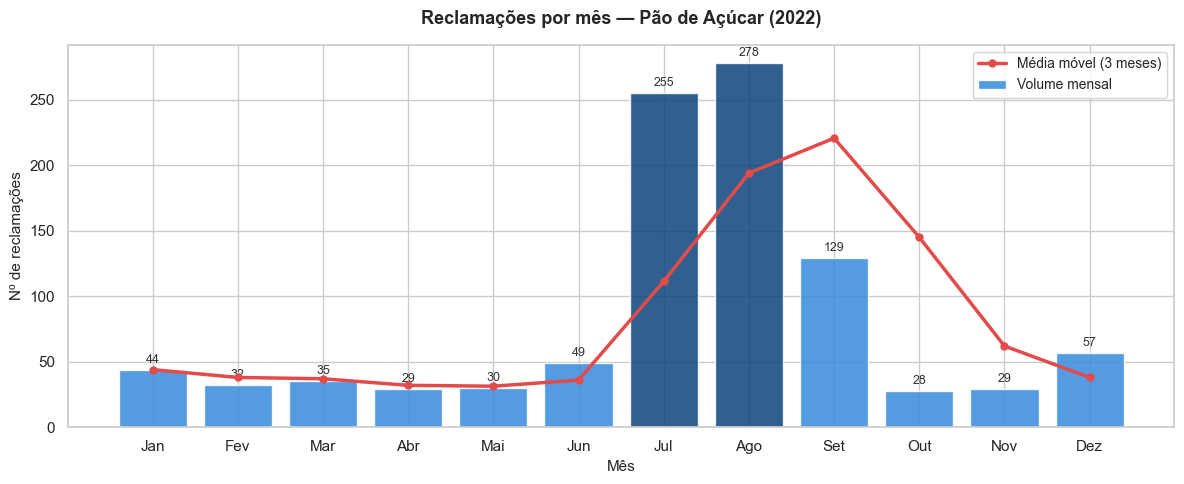

In [17]:
meses_map = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
             7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}

# Agrupamento mensal
mensal = (data.groupby('mes')
              .size()
              .reset_index(name='reclamacoes')
              .sort_values('mes'))
mensal['mes_nome']    = mensal['mes'].map(meses_map)
mensal['media_movel'] = mensal['reclamacoes'].rolling(window=3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))

# Barras
cores = ['#378ADD' if v < 200 else '#0C447C' for v in mensal['reclamacoes']]
bars = ax.bar(mensal['mes_nome'], mensal['reclamacoes'],
              color=cores, alpha=0.85, zorder=2, label='Volume mensal')

# Valores sobre as barras
for bar, val in zip(bars, mensal['reclamacoes']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontsize=9, color='#333')

# Linha de média móvel
ax.plot(mensal['mes_nome'], mensal['media_movel'],
        color='#E24B4A', linewidth=2.5, marker='o', markersize=5,
        label='Média móvel (3 meses)', zorder=3)

ax.set_xlabel('Mês', fontsize=11)
ax.set_ylabel('Nº de reclamações', fontsize=11)
ax.set_title('Reclamações por mês — Pão de Açúcar (2022)', fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.yaxis.set_major_locator(mticker.MultipleLocator(50))
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


### Interpretação

- O volume de reclamações apresenta um **pico acentuado em julho e agosto**,
  concentrando ~53% de todas as ocorrências do ano nesses dois meses.
- A **média móvel** confirma que a tendência crescente começa em junho e só
  recua expressivamente em outubro, caracterizando um problema de **sazonalidade no Q3**.
- Esse padrão sugere investigar se houve alguma **campanha promocional, mudança operacional
  ou falha sistêmica** no período julho–setembro de 2022.

## 5.2 Frequência de reclamações por dia da semana

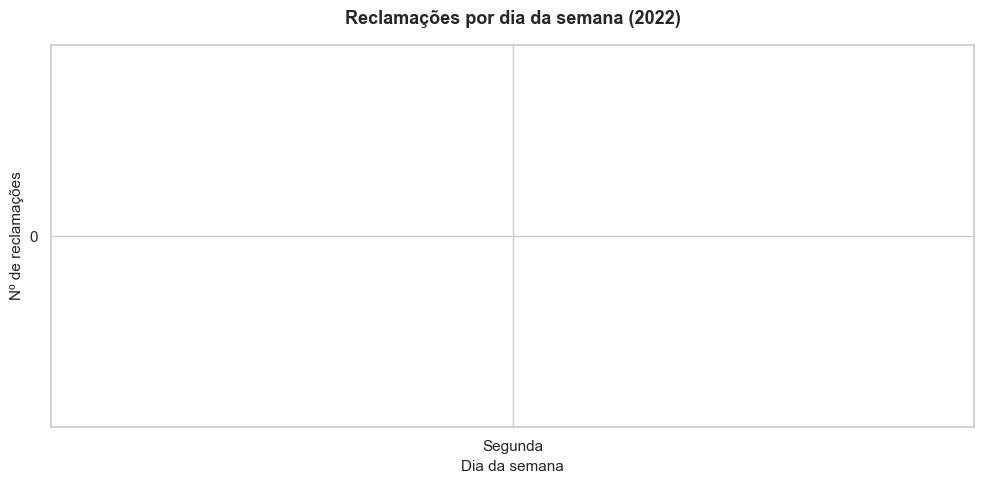

In [18]:
dias_ordem = ['Segunda','Terça','Quarta','Quinta','Sexta','Sábado','Domingo']

dia_counts = (data['dia_nome']
              .value_counts()
              .reindex(dias_ordem)
              .reset_index())
dia_counts.columns = ['dia', 'reclamacoes']

fig, ax = plt.subplots(figsize=(10, 5))

cores_dia = ['#378ADD' if d not in ['Sábado','Domingo'] else '#B5D4F4'
             for d in dia_counts['dia']]

bars = ax.bar(dia_counts['dia'], dia_counts['reclamacoes'],
              color=cores_dia, alpha=0.9, zorder=2)

for bar, val in zip(bars, dia_counts['reclamacoes']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            str(val), ha='center', va='bottom', fontsize=9, color='#333')

ax.set_xlabel('Dia da semana', fontsize=11)
ax.set_ylabel('Nº de reclamações', fontsize=11)
ax.set_title('Reclamações por dia da semana (2022)', fontsize=13, fontweight='bold', pad=15)
ax.set_axisbelow(True)
ax.yaxis.set_major_locator(mticker.MultipleLocator(25))

plt.tight_layout()
plt.show()


### Interpretação

- **Terça-feira** lidera com 174 reclamações, seguida de segunda (166) e quinta (164).
- Os **dias úteis** concentram a maioria das reclamações, mas o domingo (127) também
  apresenta volume relevante — provavelmente acúmulo de compras no fim de semana.
- Sábado tem o menor volume (98), o que pode refletir menor uso do canal digital nesse dia.

# 6. Cruzamentos Estratégicos

## 6.1 Cruzamento: STATUS × CATEGORIA

Analisamos como cada **categoria de reclamação** se distribui entre os diferentes **status de atendimento**,
revelando onde a operação do Pão de Açúcar resolve melhor — e onde falha sistematicamente.

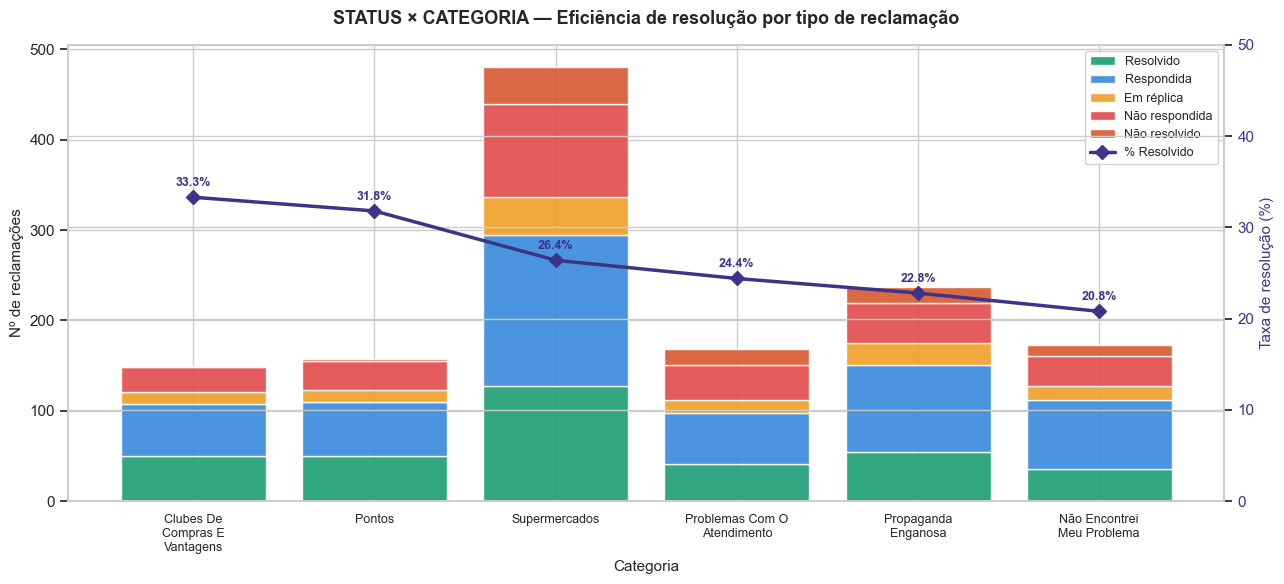

In [19]:
# Explodir categorias
data_cats = data.copy()
data_cats['categoria'] = data_cats['categoria'].str.replace('<->', ',')
data_cats['categoria'] = data_cats['categoria'].str.split(',')
data_cats = data_cats.explode('categoria').reset_index(drop=True)
data_cats['categoria'] = data_cats['categoria'].str.strip()

# Remover nome da empresa
data_cats = data_cats[~data_cats['categoria'].str.contains(
    'Pão De Açúcar|Pao De Acucar', case=False)]

# Top 6 categorias
top6 = data_cats['categoria'].value_counts().head(6).index.tolist()

# Cruzamento
cross = (data_cats[data_cats['categoria'].isin(top6)]
         .groupby(['categoria','status'])
         .size()
         .unstack(fill_value=0))

# Taxa de resolução
cross['% Resolvido'] = (cross.get('Resolvido', 0) / cross.sum(axis=1) * 100).round(1)
cross_sorted = cross.sort_values('% Resolvido', ascending=False)

# Stacked bar
status_cols  = ['Resolvido','Respondida','Em réplica','Não respondida','Não resolvido']
status_cols  = [s for s in status_cols if s in cross_sorted.columns]
cores_status = {'Resolvido':'#1D9E75','Respondida':'#378ADD',
                'Em réplica':'#EF9F27','Não respondida':'#E24B4A',
                'Não resolvido':'#D85A30'}

fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(cross_sorted))

for status in status_cols:
    vals = cross_sorted[status].values
    ax.bar(cross_sorted.index, vals, bottom=bottom,
           label=status, color=cores_status[status], alpha=0.9)
    bottom += vals

# Taxa de resolução como linha no eixo secundário
ax2 = ax.twinx()
ax2.plot(range(len(cross_sorted)), cross_sorted['% Resolvido'],
         color='#3C3489', linewidth=2.5, marker='D', markersize=7,
         label='% Resolvido', zorder=5)
for i, val in enumerate(cross_sorted['% Resolvido']):
    ax2.annotate(f'{val}%', (i, val), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=9, color='#3C3489', fontweight='bold')

ax.set_xlabel('Categoria', fontsize=11)
ax.set_ylabel('Nº de reclamações', fontsize=11)
ax2.set_ylabel('Taxa de resolução (%)', fontsize=11, color='#3C3489')
ax2.set_ylim(0, 50)
ax2.tick_params(axis='y', labelcolor='#3C3489')
ax.set_title('STATUS × CATEGORIA — Eficiência de resolução por tipo de reclamação',
             fontsize=13, fontweight='bold', pad=15)

# Wrapping labels
import textwrap
labels = [textwrap.fill(l, 15) for l in cross_sorted.index]
ax.set_xticks(range(len(cross_sorted)))
ax.set_xticklabels(labels, fontsize=9)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2,
          loc='upper right', fontsize=9, framealpha=0.9)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


### Interpretação

- **"Clubes de Compras e Vantagens"** apresenta a melhor taxa de resolução (33,3%),
  sugerindo um canal de atendimento mais estruturado para o programa de fidelidade.
- **"Não Encontrei Meu Problema"** tem a pior taxa (20,8%) — indica falha na **triagem do SAC**:
  o cliente não consegue nem categorizar seu problema, o que compromete todo o fluxo de atendimento.
- **"Propaganda Enganosa"** (22,8%) sinaliza recorrência de divergência de preços sem resolução efetiva.

## 6.2 Distribuição espacial — Gráfico de Pareto por estado

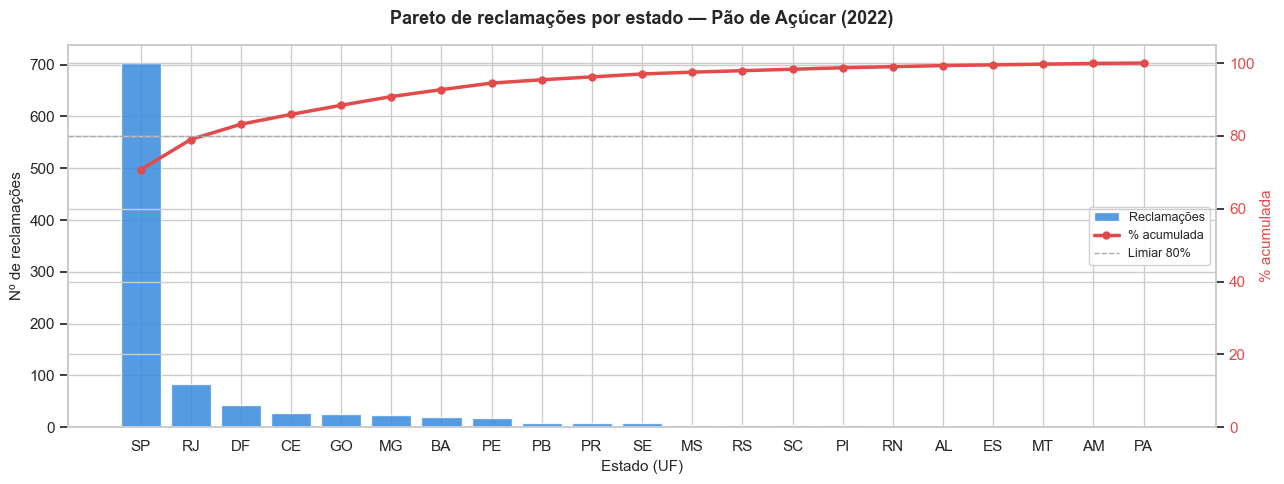

In [20]:
pareto = (data['estado']
          .value_counts()
          .reset_index())
pareto.columns = ['estado','reclamacoes']
pareto['pct_acum'] = (pareto['reclamacoes'].cumsum() /
                      pareto['reclamacoes'].sum() * 100).round(1)

fig, ax1 = plt.subplots(figsize=(13, 5))

# Barras
ax1.bar(pareto['estado'], pareto['reclamacoes'],
        color='#378ADD', alpha=0.85, zorder=2, label='Reclamações')
ax1.set_xlabel('Estado (UF)', fontsize=11)
ax1.set_ylabel('Nº de reclamações', fontsize=11)
ax1.set_axisbelow(True)

# Linha acumulada
ax2 = ax1.twinx()
ax2.plot(pareto['estado'], pareto['pct_acum'],
         color='#E24B4A', linewidth=2.5, marker='o', markersize=5,
         label='% acumulada')
ax2.axhline(80, color='#aaa', linestyle='--', linewidth=1, label='Limiar 80%')
ax2.set_ylabel('% acumulada', fontsize=11, color='#E24B4A')
ax2.set_ylim(0, 105)
ax2.tick_params(axis='y', labelcolor='#E24B4A')

ax1.set_title('Pareto de reclamações por estado — Pão de Açúcar (2022)',
              fontsize=13, fontweight='bold', pad=15)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2,
           loc='center right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()


### Interpretação

- **SP concentra 70,6%** das reclamações — um único estado domina o problema.
- Seguindo o **Princípio de Pareto**, apenas **2 estados (SP + RJ)** respondem por ~79%
  de todas as reclamações do período.
- Os 19 estados restantes somam apenas ~21% dos casos, o que direciona
  as ações corretivas prioritárias para SP e RJ.

# 7. Rascunho das Métricas do Dashboard

## Planejamento do Dashboard — Streamlit

Com base na análise exploratória realizada nas seções anteriores, definimos os componentes
visuais e as métricas que comporão o **dashboard interativo** de BI.

---

### Filtros Globais Obrigatórios

| Filtro | Tipo | Justificativa |
|---|---|---|
| **Estado** | Multiselect | SP domina 70% — essencial isolar por UF |
| **Status** | Multiselect | Taxa de resolução varia muito entre status |
| **Faixa de tamanho do texto** | Slider (min/max caracteres) | Textos longos indicam frustração acumulada |

---

### Componentes Visuais (6 obrigatórios)

**V1 — Série Temporal com Média Móvel**
- Métrica: volume diário de reclamações + linha de média móvel ajustável
- Justificativa: evidencia o pico de Jul–Ago e a tendência do Q3

**V2 — Mapa Coroplético do Brasil**
- Métrica: reclamações por estado com intensidade de cor
- Justificativa: visualização imediata da concentração geográfica em SP

**V3 — Gráfico de Pareto por Estado**
- Métrica: volume absoluto + % acumulada por UF
- Justificativa: demonstra que 2 estados = 79% do problema

**V4 — Proporção de Resoluções (STATUS)**
- Métrica: frequência de cada status em donut chart + barras
- Justificativa: evidencia o gargalo de 26,5% de resolução efetiva

**V5 — Distribuição do Tamanho dos Textos × STATUS**
- Métrica: boxplot de caracteres da DESCRICAO por status
- Justificativa: "Em réplica" tem média 34% maior — sinal de frustração

**V6 — WordCloud com NLP**
- Métrica: palavras mais frequentes nas descrições (sem stopwords)
- Justificativa: revela os termos reais dos problemas (estorno, entrega, pontos)
- Biblioteca: `nltk` com stopwords em português

---

### Tecnologia
- **Framework:** Streamlit
- **Gráficos:** Plotly Express + Matplotlib (WordCloud)
- **NLP:** NLTK (stopwords PT-BR)
- **Deploy:** Streamlit Community Cloud